Epoch 1/100


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 67.5079 - val_loss: 53.3525
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 40.8773 - val_loss: 37.8712
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 20.4815 - val_loss: 24.3887
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 17.5199 - val_loss: 18.4016
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 18.1407 - val_loss: 17.4745
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 14.3899 - val_loss: 16.7568
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 14.8144 - val_loss: 17.6551
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 11.8402 - val_loss: 19.4015
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 11.2133 - val_loss: 19.4073
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 10.3247 - val_loss: 15.0332
Epoch 11/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.3680 - val_loss: 9.3505
Epoch 12/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4106 - val_loss:

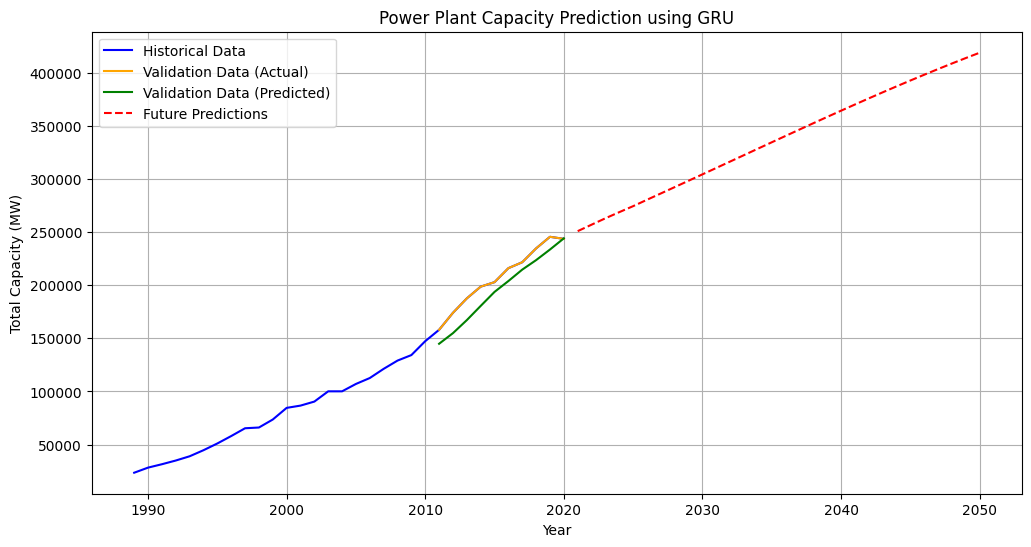

In [26]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense

# Load dataset
data = pd.read_excel("/Users/workk/Documents/[Think!]/[FMK]/Research Things/Forecasting/[DRAFT]/Proceeding/Data.xlsx")  # Replace with your file path
years = data['Year'].values
total_capacity = data['TotalKap'].values

# Normalize the data for GRU
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(total_capacity.reshape(-1, 1))

# Prepare data for sequence modeling
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i + sequence_length])
        y.append(data[i + sequence_length])
    return np.array(X), np.array(y)

sequence_length = 5
X, y = create_sequences(scaled_data, sequence_length)

# Split into training and validation sets
train_size = len(data[data['Year'] < 2011])
X_train, y_train = X[:train_size - sequence_length], y[:train_size - sequence_length]
X_val, y_val = X[train_size - sequence_length:], y[train_size - sequence_length:]

# Build GRU model
model = Sequential([
    GRU(50, activation='tanh', return_sequences=False, input_shape=(sequence_length, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mean_absolute_percentage_error')

# Train the model
model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100, batch_size=8, verbose=1)

# Validate the model
val_predictions = model.predict(X_val)
val_predictions = scaler.inverse_transform(val_predictions)
y_val_rescaled = scaler.inverse_transform(y_val)

# Calculate MAPE for validation set
mape = np.mean(np.abs((y_val_rescaled.flatten() - val_predictions.flatten()) / y_val_rescaled.flatten())) * 100
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

# Forecast future values
future_predictions = []
input_sequence = scaled_data[-sequence_length:]

for _ in range(30):  # Predict for 30 years
    prediction = model.predict(input_sequence[np.newaxis, :, :])
    future_predictions.append(prediction[0, 0])
    input_sequence = np.append(input_sequence[1:], prediction, axis=0)

future_predictions = scaler.inverse_transform(np.array(future_predictions).reshape(-1, 1))

# Prepare output data for validation (actual vs. predicted)
validation_years = data[(data['Year'] >= 2011) & (data['Year'] <= 2020)]['Year'].values
actual_vs_predicted = pd.DataFrame({
    "Year": validation_years,
    "Actual Capacity (MW)": y_val_rescaled.flatten(),
    "Predicted Capacity (MW)": val_predictions.flatten()
})

# Prepare output data for future predictions
future_output = pd.DataFrame({
    "Year": list(range(2021, 2051)),
    "Predicted Capacity (MW)": future_predictions.flatten()
})

# Display validation data
print("\nValidation Data: Actual vs. Predicted")
print(actual_vs_predicted)

# Display future predictions
print("\nFuture Predictions")
print(future_output)

# Save results to Excel
output_file_path = "/Users/workk/Downloads/GRU.xlsx"  # Replace with your desired path
with pd.ExcelWriter(output_file_path, engine='openpyxl') as writer:
    actual_vs_predicted.to_excel(writer, sheet_name="Validation Data", index=False)
    future_output.to_excel(writer, sheet_name="Future Predictions", index=False)

print(f"\nPredictions and validation summary saved to {output_file_path}")

# Plot results
plt.figure(figsize=(12, 6))
plt.plot(years, total_capacity, label="Historical Data", color="blue")
plt.plot(validation_years, y_val_rescaled.flatten(), label="Validation Data (Actual)", color="orange")
plt.plot(validation_years, val_predictions.flatten(), label="Validation Data (Predicted)", color="green")
plt.plot(range(2021, 2051), future_predictions.flatten(), label="Future Predictions", color="red", linestyle="--")
plt.xlabel("Year")
plt.ylabel("Total Capacity (MW)")
plt.title("Power Plant Capacity Prediction using GRU")
plt.legend()
plt.grid()
plt.show()

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Provided actual and predicted data
actual = np.array([
    157992.66, 173990.75, 187541.02, 198601.78, 202845.82, 
    216004.32, 221574.66, 234617.88, 245518.20, 243582.73
])

predictedbySymbolic1 = np.array([
    144854.203125, 154840.484375, 167102.593750, 180460.875000, 193665.859375,
    203883.796875, 214634.312500, 223568.812500, 233538.734375, 244050.015625
])

# Calculate MAPE for each model
def calculate_mape(actual, predicted):
    return np.mean(np.abs((actual - predicted) / actual)) * 100

# Calculate R-Squared for each model
def calculate_r2(actual, predicted):
    return np.subtract(1,(np.divide(np.sum(np.power((np.subtract(actual,predicted)),2)),np.sum(np.power(np.subtract(actual,np.mean(actual)),2)))))

mape_symbolic1 = calculate_mape(actual, predictedbySymbolic1)
print(f"MAPE for Symbolic 1: {mape_symbolic1:.2f}%")

r2_symbolic1 = calculate_r2(actual, predictedbySymbolic1)
print(f"R-Squared for Symbolic 1: {r2_symbolic1:.2f}")

MAPE for Symbolic 1: 6.24%
R-Squared for Symbolic 1: 0.77


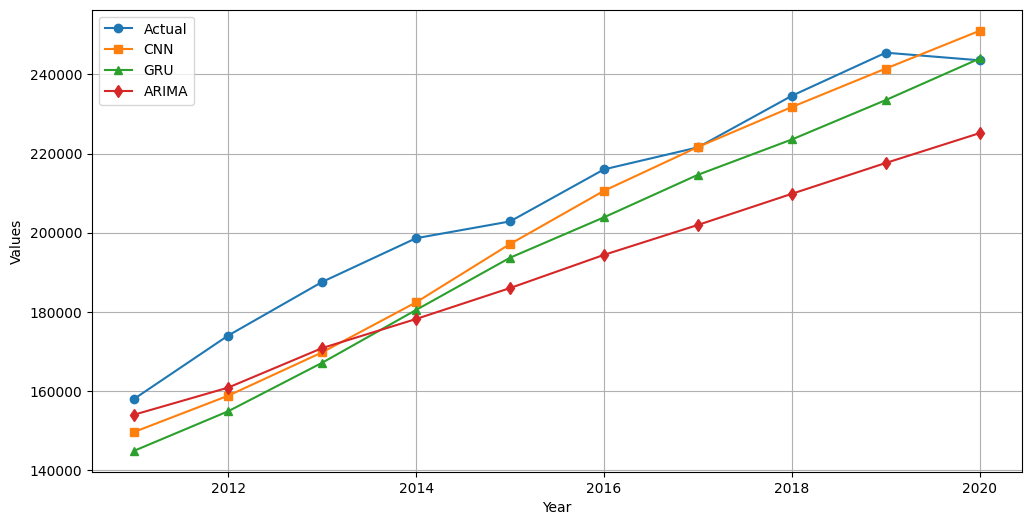

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Data preparation
data = {
    "Year": [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020],
    "Actual": [157992.7, 173990.8, 187541, 198601.8, 202845.8, 216004.3, 221574.7, 234617.9, 245518.2, 243582.7],
    "CNN": [149613.1875, 158774.171875, 169737.625, 182385.953125, 197128.6875, 210588.171875, 221661.984375, 231782.75, 241502.78125, 251069.578125],
    "GRU": [144854.2, 154840.5, 167102.6, 180460.9, 193665.9, 203883.8, 214634.3, 223568.8, 233538.7, 244050],
    "ARIMA": [153979.019, 160825.1542, 170812.5701, 178170.0217, 185992.9069, 194384.4305, 201955.4239, 209830.3513, 217628.1663, 225181.8523]
}

df = pd.DataFrame(data)

# Plotting the validation chart
plt.figure(figsize=(12, 6))
plt.plot(df["Year"], df["Actual"], label="Actual", marker='o')
plt.plot(df["Year"], df["CNN"], label="CNN", marker='s')
plt.plot(df["Year"], df["GRU"], label="GRU", marker='^')
plt.plot(df["Year"], df["ARIMA"], label="ARIMA", marker='d')

#plt.title("Forecasting Validation")
plt.xlabel("Year")
plt.ylabel("Values")
plt.legend()
plt.grid(True)
plt.show()